# Imports & Directory Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import os
import time
from multiprocess import Pool, cpu_count

# Create necessary directories for outputs
os.makedirs("mcmc_chains", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Prevent internal SciPy/NumPy multithreading conflicts during MCMC parallelization
os.environ["OMP_NUM_THREADS"] = "1"
print("Environment initialized successfully.")

Environment initialized successfully.


# Load Cosmic Chronometer Dataset

In [2]:
# ---------------------------------------------------------
# Load Cosmic Chronometers (CC) Data (With Numerical Type-Casting)
# ---------------------------------------------------------
try:
    df_cc = pd.read_csv('../../data/CC.txt', sep=r'\s+', comment='#', names=['z', 'Hz', 'err_Hz'])
except FileNotFoundError:
    df_cc = pd.read_csv('../../data/CC.txt', sep=r'\s+')

# --- THE CRITICAL FIX: FORCE NUMERICAL FLOATING-POINT CONVERSION ---
# This guarantees no strings are passed into NumPy's math functions!
for col in ['z', 'Hz', 'err_Hz']:
    df_cc[col] = pd.to_numeric(df_cc[col], errors='coerce')

# Drop any rows that accidentally failed conversion (e.g., leftover text headers)
df_cc = df_cc.dropna().reset_index(drop=True)

N_cc = len(df_cc)
print(f"Cosmic Chronometer dataset loaded and type-casted successfully: {N_cc} data points.")
print(df_cc.dtypes)  # Verify that all columns now explicitly read 'float64'
print(df_cc.head())

Cosmic Chronometer dataset loaded and type-casted successfully: 32 data points.
z         float64
Hz        float64
err_Hz    float64
dtype: object
       z    Hz  err_Hz
0  0.070  69.0    19.6
1  0.090  69.0    12.0
2  0.120  68.6    26.2
3  0.170  83.0     8.0
4  0.179  75.0     4.0


# CPL Theoretical Model & Likelihood Engine

In [3]:
# ---------------------------------------------------------
# CPL Physics & CC Likelihood Engine (4 Parameters)
# ---------------------------------------------------------

def H_CPL(z, Omega_m, H_0, w0, wa):
    """
    Theoretical Hubble parameter H(z) for CPL dark energy in a flat universe.
    w(z) = w0 + wa * (z / (1 + z))
    """
    term_matter = Omega_m * (1.0 + z)**3
    
    # CPL dark energy density evolution
    exponent = 3.0 * (1.0 + w0 + wa)
    exponential_term = np.exp(-3.0 * wa * (z / (1.0 + z)))
    term_de = (1.0 - Omega_m) * ((1.0 + z)**exponent) * exponential_term
    
    return H_0 * np.sqrt(term_matter + term_de)

def log_prior(params):
    Omega_m, H_0, w0, wa = params
    
    # Flat, uninformative uniform bounding box
    bounds_check = (
        (0.01 < Omega_m < 0.99) and 
        (40.0 < H_0 < 100.0) and 
        (-3.0 < w0 < 1.0) and 
        (-3.0 < wa < 3.0)
    )
    if not bounds_check:
        return -np.inf
        
    return 0.0

def log_posterior_cc(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
        
    Omega_m, H_0, w0, wa = params
    
    # Calculate theoretical H(z) for each observed redshift
    Hz_th = H_CPL(df_cc['z'].values, Omega_m, H_0, w0, wa)
    
    # Gaussian log-likelihood (assuming independent measurements / diagonal covariance)
    residuals = df_cc['Hz'].values - Hz_th
    chi2 = np.sum((residuals / df_cc['err_Hz'].values)**2)
    
    ll_cc = -0.5 * (chi2 + np.sum(np.log(2.0 * np.pi * (df_cc['err_Hz'].values**2))))
    
    return lp + ll_cc

# Uniform Random Initialization & MCMC Execution

In [4]:
# ---------------------------------------------------------
# MCMC Execution with Gelman-Rubin Early Stopping
# ---------------------------------------------------------
def compute_gelman_rubin(chain):
    """Calculates R-hat convergence diagnostic across all parameter dimensions."""
    nsteps, nwalkers, ndim = chain.shape
    R_hat = np.zeros(ndim)
    for d in range(ndim):
        samples = chain[:, :, d]
        W = np.mean(np.var(samples, axis=0, ddof=1))
        chain_means = np.mean(samples, axis=0)
        grand_mean = np.mean(chain_means)
        B = (nsteps / (nwalkers - 1.0)) * np.sum((chain_means - grand_mean)**2)
        V_hat = ((nsteps - 1.0) / nsteps) * W + (B / nsteps)
        R_hat[d] = np.sqrt(V_hat / W) if W > 0 else np.inf
    return R_hat

# Configuration
ndim = 4  # (Omega_m, H_0, w0, wa)
nwalkers = 50
max_steps = 25000
check_interval = 200
R_hat_threshold = 1.02 

# Define prior bounding ranges for uniform random initialization
prior_bounds = [
    (0.01, 0.99),   # Omega_m
    (50.0, 90.0),   # H_0
    (-2.5, 0.5),    # w0
    (-2.5, 2.5)     # wa
]

# Initialize walkers uniformly across the full parameter space
initial_pos = np.zeros((nwalkers, ndim))
for i in range(ndim):
    low, high = prior_bounds[i]
    initial_pos[:, i] = np.random.uniform(low, high, size=nwalkers)

print("Walkers initialized uniformly across prior boundaries.")

# Set up HDF5 backend for permanent disk storage
h5_filename = "mcmc_chains/cpl_cc.h5"
backend = emcee.backends.HDFBackend(h5_filename)
backend.reset(nwalkers, ndim)

ncpu = int(max(1, cpu_count() - 2))
print(f"\nStarting CC-Only MCMC on {ncpu} cores (Max {max_steps} steps)...")

start_time = time.time()
with Pool(processes=ncpu) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_posterior_cc, 
        pool=pool, backend=backend
    )
    
    for sample in sampler.sample(initial_pos, iterations=max_steps, progress=True):
        if sampler.iteration % check_interval == 0 and sampler.iteration > 0:
            chain = sampler.get_chain()
            burn_in = int(chain.shape[0] * 0.5)
            R_hat = compute_gelman_rubin(chain[burn_in:, :, :])
            
            if np.all(R_hat < R_hat_threshold):
                print(f"\n✅ Gelman-Rubin convergence achieved at step {sampler.iteration}!")
                print(f"Final R-hat values: {np.round(R_hat, 4)}")
                break

end_time = time.time()
print(f"\nMCMC complete! Time taken: {(end_time - start_time) / 60:.2f} minutes.")
print(f"Chain saved permanently to: {h5_filename}")

Walkers initialized uniformly across prior boundaries.

Starting CC-Only MCMC on 18 cores (Max 25000 steps)...


 29%|██████████████████████▏                                                      | 7200/25000 [05:09<12:45, 23.24it/s]


✅ Gelman-Rubin convergence achieved at step 7200!
Final R-hat values: [1.0192 1.0127 1.0129 1.009 ]

MCMC complete! Time taken: 5.17 minutes.
Chain saved permanently to: mcmc_chains/cpl_cc.h5


# Read Directly from .h5 File & Plot Diagnostics

Successfully loaded mcmc_chains/cpl_cc.h5
Chain Dimensions -> Steps: 7200, Walkers: 50, Params: 4
Trace plot saved to: plots/cpl_cc_trace.png


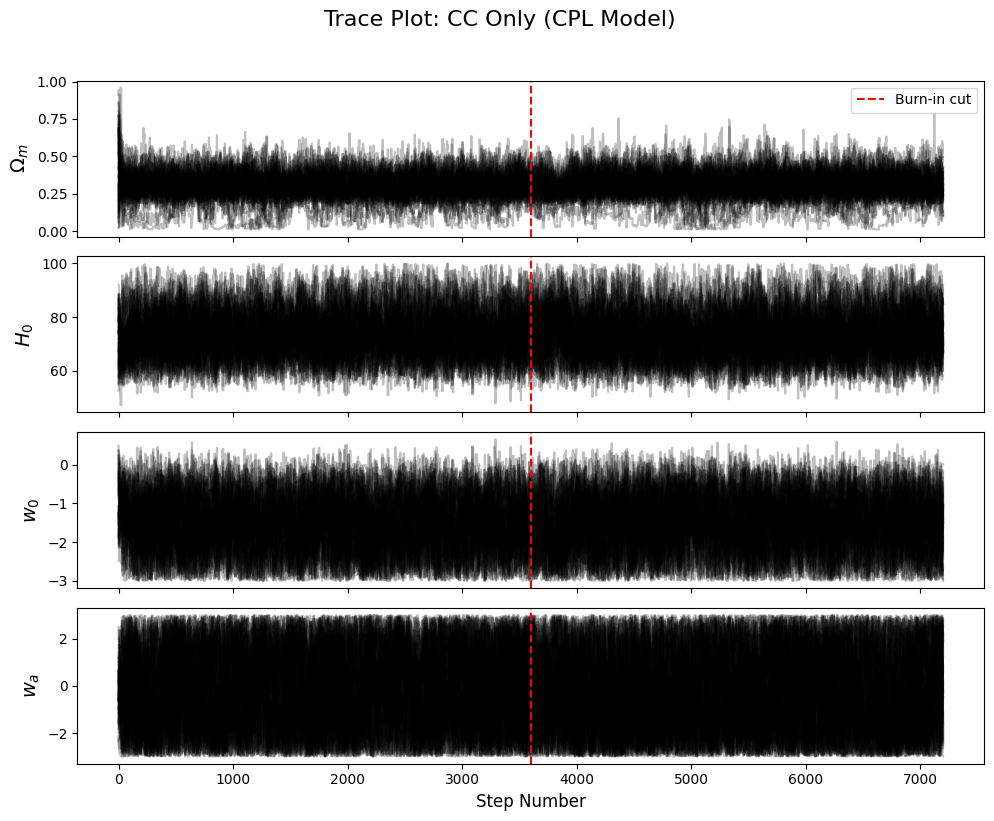

Continuous corner plot saved to: plots/cpl_cc_corner.png


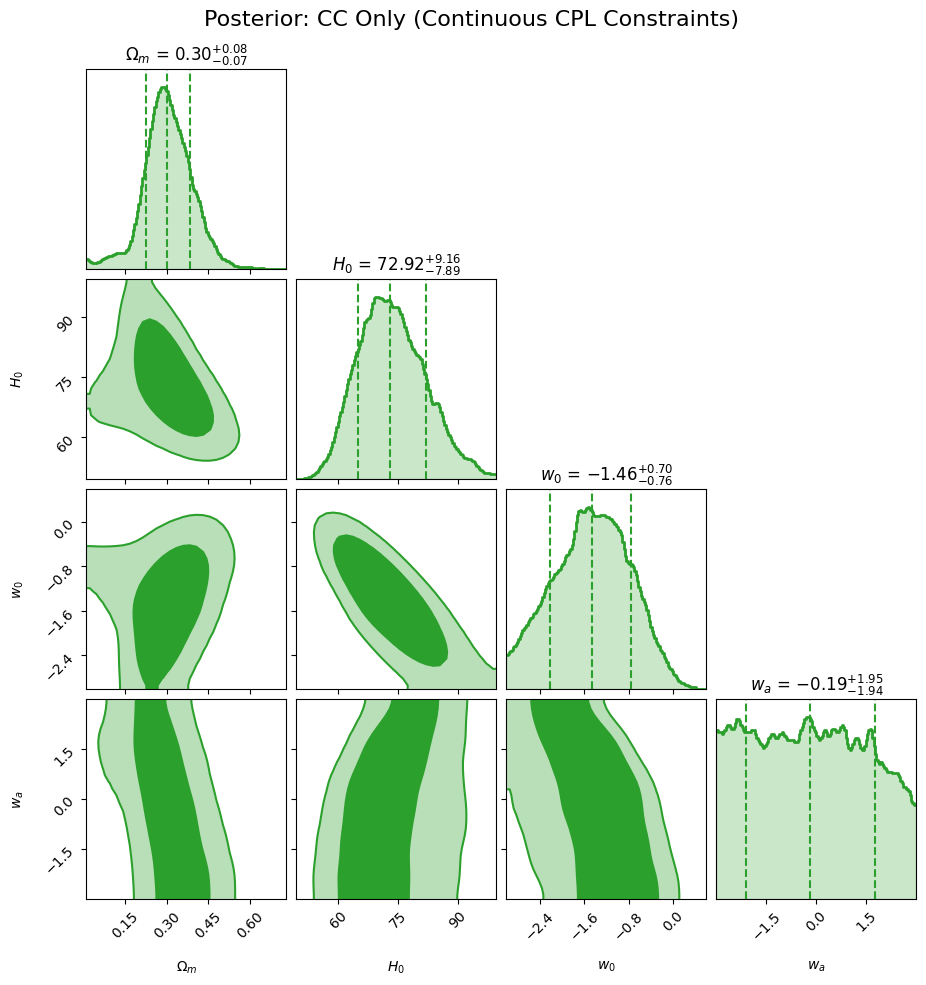

In [5]:
# ---------------------------------------------------------
# Read from .h5 File & Plot Continuous Constraints
# ---------------------------------------------------------
h5_filename = "mcmc_chains/cpl_cc.h5"
trace_save_path = "plots/cpl_cc_trace.png"
corner_save_path = "plots/cpl_cc_corner.png"

try:
    # Read chain from disk
    reader = emcee.backends.HDFBackend(h5_filename)
    full_chain = reader.get_chain()
    
    total_steps, nwalkers, ndim = full_chain.shape
    print(f"Successfully loaded {h5_filename}")
    print(f"Chain Dimensions -> Steps: {total_steps}, Walkers: {nwalkers}, Params: {ndim}")
    
    # Dynamic 50% burn-in discard
    discard_steps = int(total_steps * 0.5)
    thin_steps = 15
    flat_samples = reader.get_chain(discard=discard_steps, thin=thin_steps, flat=True)
    
    labels = [r"$\Omega_m$", r"$H_0$", r"$w_0$", r"$w_a$"]
    
    # -----------------------------------------------------
    # 1. TRACE PLOT
    # -----------------------------------------------------
    fig, axes = plt.subplots(ndim, figsize=(10, 8), sharex=True)
    for i in range(ndim):
        axes[i].plot(full_chain[:, :, i], "k", alpha=0.25)
        axes[i].set_ylabel(labels[i], fontsize=14)
        axes[i].axvline(x=discard_steps, color='red', linestyle='--', label='Burn-in cut')
        if i == 0: 
            axes[i].legend(loc='upper right')
        
    axes[-1].set_xlabel("Step Number", fontsize=12)
    plt.suptitle("Trace Plot: CC Only (CPL Model)", y=1.02, fontsize=16)
    plt.tight_layout()
    
    plt.savefig(trace_save_path, dpi=300, bbox_inches='tight')
    print(f"Trace plot saved to: {trace_save_path}")
    plt.show()

    # -----------------------------------------------------
    # 2. CONTINUOUS 2-REGION CORNER PLOT
    # -----------------------------------------------------
    fig = corner.corner(
        flat_samples, 
        labels=labels,
        quantiles=[0.16, 0.5, 0.84], 
        show_titles=True,
        title_kwargs={"fontsize": 12},
        
        # Continuous & Filled Contour Styling
        levels=[0.68, 0.95],        # 1-sigma (68%) and 2-sigma (95%) regions
        fill_contours=True,         # Solid shaded regions
        plot_datapoints=False,      # Hide individual scatter points
        plot_density=False,         # Remove interior background gradient
        smooth=2,                 # Gaussian smoothing for 2D contours
        smooth1d=2,               # Gaussian smoothing for 1D diagonal curves
        bins=30,                    # Base histogram resolution
        hist_bin_factor=5,          # Super-resolution factor for continuous 1D curves
        
        # Styling parameters
        color='#2ca02c',            # Green theme to visually distinguish CC from SNe (blue)
        hist_kwargs={
            'linewidth': 2.0,       # Smooth continuous line outline
            'alpha': 1.0
        }
    )
    
    # Manually apply shaded fill beneath the continuous 1D diagonal curves
    for i in range(ndim):
        ax = fig.axes[i * ndim + i]
        for line in ax.get_lines():
            x_data, y_data = line.get_data()
            ax.fill_between(x_data, 0, y_data, color='#2ca02c', alpha=0.25)
            
    plt.suptitle("Posterior: CC Only (Continuous CPL Constraints)", y=1.02, fontsize=16)
    
    plt.savefig(corner_save_path, dpi=300, bbox_inches='tight')
    print(f"Continuous corner plot saved to: {corner_save_path}")
    plt.show()
    
except FileNotFoundError:
    print(f"Error: Could not find {h5_filename}. Please run the MCMC execution cell first!")